In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import matplotlib.pyplot as plt

In [24]:

# Load the Excel file from the "Data-Base" folder
Adolescents_out_school = pd.read_excel("Data-Base/Adolescents_out_school.xls")

In [25]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# missing_mask = Adolescents_out_school["2022"].isna()
# missing_countries = Adolescents_out_school.loc[missing_mask, "Country Name"]
# print("Countries with missing 2022 values:", missing_countries.tolist())

# Randome forest

In [26]:
# Extract years as features
years = [str(y) for y in range(1960, 2023)]
X = Adolescents_out_school[years]

# Separate features and target (2022)
X_train = X.drop(columns=["2022"])
y_train = X["2022"]

# Mask rows with missing 2022
mask_missing = y_train.isna()

# Train model only on rows with known 2022
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train[~mask_missing], y_train[~mask_missing])

# Predict missing 2022 values
y_pred = rf.predict(X_train[mask_missing])

# Estimate confidence: standard deviation across trees
all_tree_preds = np.stack([t.predict(X_train[mask_missing]) for t in rf.estimators_], axis=1)
std_dev = all_tree_preds.std(axis=1)

# Store predictions
Adolescents_out_school.loc[mask_missing, "2022_predicted"] = y_pred
Adolescents_out_school.loc[mask_missing, "2022_confidence"] = 1 / (1 + std_dev)  # Higher = more confident

print(Adolescents_out_school.loc[mask_missing, ["Country Name", "2022_predicted", "2022_confidence"]])


C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Spor

                    Country Name  2022_predicted  2022_confidence
0                          Aruba        7.983789         0.080137
1    Africa Eastern and Southern        6.918467         0.071563
2                    Afghanistan        6.890259         0.072181
3     Africa Western and Central        6.918467         0.071563
4                         Angola        7.945501         0.071228
..                           ...             ...              ...
259                        World        6.918467         0.071563
261                       Kosovo        6.918467         0.071563
262                  Yemen, Rep.       12.564211         0.059126
264                       Zambia        6.918467         0.071563
265                     Zimbabwe        9.529101         0.075287

[136 rows x 3 columns]


C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Sport\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\DELL\.conda\envs\Spor

In [27]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2022_predicted,2022_confidence
0,Aruba,ABW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.983789,0.080137
1,Africa Eastern and Southern,AFE,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.918467,0.071563
2,Afghanistan,AFG,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.890259,0.072181
3,Africa Western and Central,AFW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.918467,0.071563
4,Angola,AGO,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.945501,0.071228


In [28]:
missing_mask = Adolescents_out_school["2022"].isna()
missing_countries = Adolescents_out_school.loc[missing_mask, "Country Name"]
print("Countries with missing 2022 values:", missing_countries.tolist())

Countries with missing 2022 values: ['Aruba', 'Africa Eastern and Southern', 'Afghanistan', 'Africa Western and Central', 'Angola', 'Arab World', 'United Arab Emirates', 'American Samoa', 'Antigua and Barbuda', 'Burundi', 'Bahamas, The', 'Bermuda', 'Central African Republic', 'Central Europe and the Baltics', 'Channel Islands', 'China', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Comoros', 'Cabo Verde', 'Caribbean small states', 'Curacao', 'Cayman Islands', 'Djibouti', 'Algeria', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Egypt, Arab Rep.', 'Euro area', 'European Union', 'Fragile and conflict affected situations', 'Faroe Islands', 'Gabon', 'Ghana', 'Gibraltar', 'Guinea', 'Gambia, The', 'Guinea-Bissau', 'Equatorial Guinea', 'Grenada', 'Greenland', 'Guam', 'Guyana', 'Heavily indebted poor countries (HIPC)', 'Croatia', 'Haiti', 'IBRD only', 'IDA & IBRD total', 'IDA t

In [29]:
# Select only required columns
new_Adolescents_out_school = Adolescents_out_school[[
    "Country Name", 
    "Country Code", 
    "2022", 
    "2022_predicted", 
    "2022_confidence"
]]

In [30]:
new_Adolescents_out_school.head(50)

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,NaN,7.983789,0.080137
1,Africa Eastern and Southern,AFE,NaN,6.918467,0.071563
2,Afghanistan,AFG,NaN,6.890259,0.072181
3,Africa Western and Central,AFW,NaN,6.918467,0.071563
4,Angola,AGO,NaN,7.945501,0.071228
5,Albania,ALB,2.749650,NaN,NaN
6,Andorra,AND,7.337280,NaN,NaN
7,Arab World,ARB,NaN,6.918467,0.071563
8,United Arab Emirates,ARE,NaN,9.062317,0.106807
9,Argentina,ARG,1.019580,NaN,NaN


In [17]:
# Keep only rows where 2022 column is NOT missing
non_missing_2022 = new_Adolescents_out_school[new_Adolescents_out_school["2022"].notna()]

In [18]:
non_missing_2022.head()

,Country Name,Country Code,2022,2022_predicted,2022_confidence
5,Albania,ALB,2.74965,NaN,NaN
6,Andorra,AND,7.33728,NaN,NaN
9,Argentina,ARG,1.01958,NaN,NaN
10,Armenia,ARM,0.41723,NaN,NaN
13,Australia,AUS,1.64652,NaN,NaN


In [31]:

# Case 1: If 2022 is NaN → replace it with 2022_predicted (keep confidence as-is)
mask_2022_missing = new_Adolescents_out_school["2022"].isna()
new_Adolescents_out_school.loc[mask_2022_missing, "2022"] = new_Adolescents_out_school.loc[mask_2022_missing, "2022_predicted"]

# Case 2: If 2022_predicted is NaN → replace it with 2022 and force confidence = 1
mask_pred_missing = new_Adolescents_out_school["2022_predicted"].isna()
new_Adolescents_out_school.loc[mask_pred_missing, "2022_predicted"] = new_Adolescents_out_school.loc[mask_pred_missing, "2022"]
new_Adolescents_out_school.loc[mask_pred_missing, "2022_confidence"] = 1


In [32]:
new_Adolescents_out_school.head(50)

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,7.983789,7.983789,0.080137
1,Africa Eastern and Southern,AFE,6.918467,6.918467,0.071563
2,Afghanistan,AFG,6.890259,6.890259,0.072181
3,Africa Western and Central,AFW,6.918467,6.918467,0.071563
4,Angola,AGO,7.945501,7.945501,0.071228
5,Albania,ALB,2.749650,2.749650,1.000000
6,Andorra,AND,7.337280,7.337280,1.000000
7,Arab World,ARB,6.918467,6.918467,0.071563
8,United Arab Emirates,ARE,9.062317,9.062317,0.106807
9,Argentina,ARG,1.019580,1.019580,1.000000


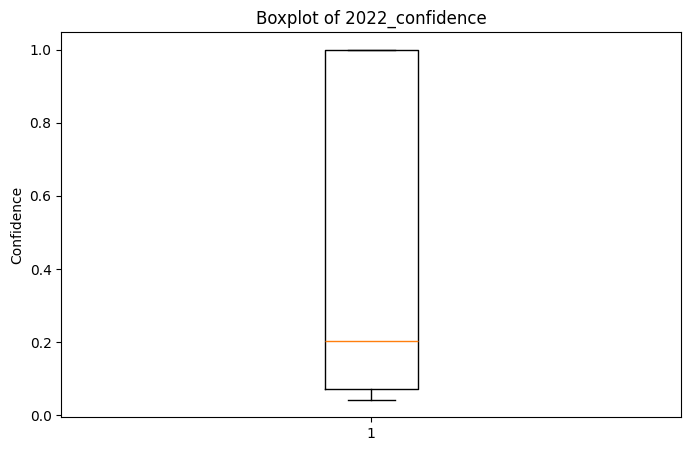

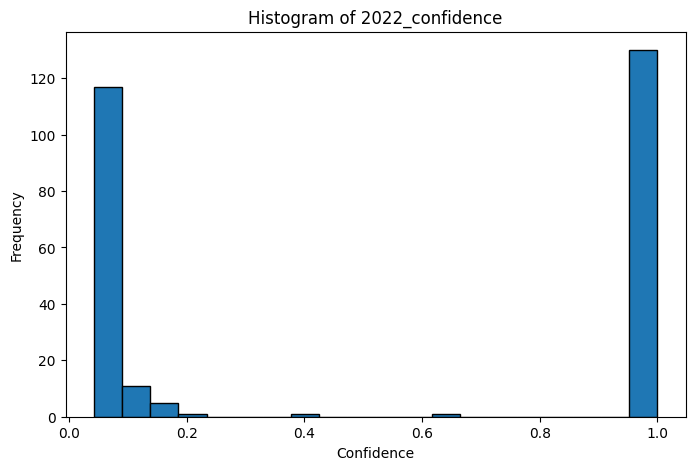

In [33]:
import matplotlib.pyplot as plt

# Assuming new_Adolescents_out_school dataframe is already available in memory

# Create a boxplot for 2022_confidence
plt.figure(figsize=(8,5))
plt.boxplot(new_Adolescents_out_school["2022_confidence"].dropna(), vert=True)
plt.title("Boxplot of 2022_confidence")
plt.ylabel("Confidence")
plt.show()

# Create a histogram for 2022_confidence
plt.figure(figsize=(8,5))
plt.hist(new_Adolescents_out_school["2022_confidence"].dropna(), bins=20, edgecolor='black')
plt.title("Histogram of 2022_confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


# xgboost 

In [38]:
# Load the Excel file from the "Data-Base" folder
Adolescents_out_school = pd.read_excel("Data-Base/Adolescents_out_school.xls")

In [39]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Adolescents out of school (% of lower secondar...,SE.SEC.UNER.LO.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# !pip install xgboost  # uncomment if needed
import xgboost as xgb

# ---- CONFIG ----
B = 50  # number of bootstrap models (increase for smoother confidence)
RANDOM_STATE = 42
xgb_params = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
)

# ---- DATA ----
# Adolescents_out_school: columns include 'Country Name','Country Code',
# and year columns '1960'...'2024' as strings.
years = [str(y) for y in range(1960, 2024)]
feature_years = [y for y in years if y != "2022"]  # exclude target

X_all = Adolescents_out_school[feature_years]
y_all = Adolescents_out_school["2022"]

mask_missing = y_all.isna()
idx_train = np.where(~mask_missing)[0]
idx_miss  = np.where(mask_missing)[0]

X_train = X_all.iloc[idx_train]
y_train = y_all.iloc[idx_train]
X_miss  = X_all.iloc[idx_miss]

# ---- BOOTSTRAP + XGBoost ----
# Train B bootstrap models on known 2022 rows; predict missing rows each time
rng = np.random.default_rng(RANDOM_STATE)
preds_matrix = np.zeros((len(idx_miss), B))

for b in range(B):
    # bootstrap sample of training indices
    boot_idx = rng.choice(len(idx_train), size=len(idx_train), replace=True)
    Xb = X_train.iloc[boot_idx]
    yb = y_train.iloc[boot_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(Xb, yb)
    preds_matrix[:, b] = model.predict(X_miss)

# ---- AGGREGATE PREDICTIONS + CONFIDENCE ----
y_pred = preds_matrix.mean(axis=1)
std_dev = preds_matrix.std(axis=1)

# Relative confidence: higher = more stable across models
rel_conf = 1.0 / (1.0 + std_dev)

# ---- WRITE BACK ----
Adolescents_out_school["2022_predicted"] = np.nan
Adolescents_out_school["2022_confidence"] = np.nan

Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = y_pred
Adolescents_out_school.loc[mask_missing, "2022_confidence"] = rel_conf

# (Optional) Set confidence=1 for rows with observed 2022
Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0

                                    Country Name Country Code  2022_predicted  \
130                                      Lebanon          LBN       21.187155   
242                          Trinidad and Tobago          TTO       21.274316   
247                                       Uganda          UGA       25.912178   
88                             Equatorial Guinea          GNQ        8.872850   
40                                         China          CHN        8.882422   
36                Central Europe and the Baltics          CEB        8.882422   
1                    Africa Eastern and Southern          AFE        8.882422   
3                     Africa Western and Central          AFW        8.882422   
61   East Asia & Pacific (excluding high income)          EAP        8.882422   
62                    Early-demographic dividend          EAR        8.882422   

     2022_confidence  
130         0.064134  
242         0.065476  
247         0.075649  
88          0.07

In [41]:
# Select only required columns
new_Adolescents_out_school = Adolescents_out_school[[
    "Country Name", 
    "Country Code", 
    "2022", 
    "2022_predicted", 
    "2022_confidence"
]]

In [42]:
# Case 1: If 2022 is NaN → replace it with 2022_predicted (keep confidence as-is)
mask_2022_missing = new_Adolescents_out_school["2022"].isna()
new_Adolescents_out_school.loc[mask_2022_missing, "2022"] = new_Adolescents_out_school.loc[mask_2022_missing, "2022_predicted"]

# Case 2: If 2022_predicted is NaN → replace it with 2022 and force confidence = 1
mask_pred_missing = new_Adolescents_out_school["2022_predicted"].isna()
new_Adolescents_out_school.loc[mask_pred_missing, "2022_predicted"] = new_Adolescents_out_school.loc[mask_pred_missing, "2022"]
new_Adolescents_out_school.loc[mask_pred_missing, "2022_confidence"] = 1

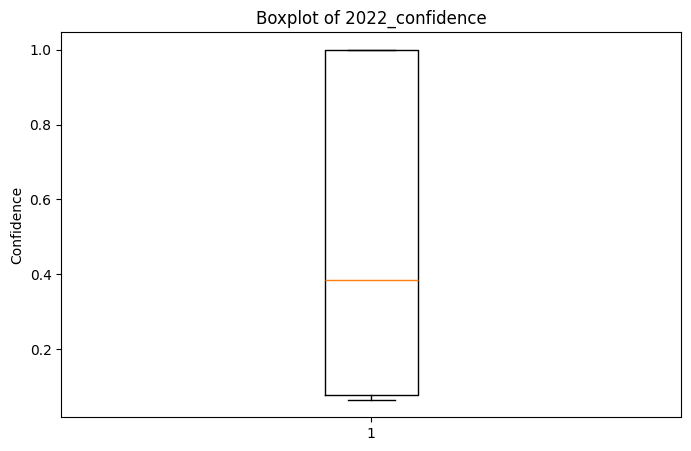

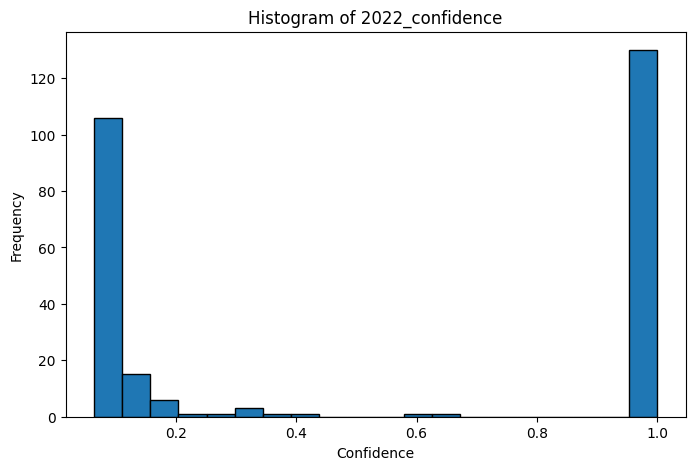

In [43]:
import matplotlib.pyplot as plt

# Assuming new_Adolescents_out_school dataframe is already available in memory

# Create a boxplot for 2022_confidence
plt.figure(figsize=(8,5))
plt.boxplot(new_Adolescents_out_school["2022_confidence"].dropna(), vert=True)
plt.title("Boxplot of 2022_confidence")
plt.ylabel("Confidence")
plt.show()

# Create a histogram for 2022_confidence
plt.figure(figsize=(8,5))
plt.hist(new_Adolescents_out_school["2022_confidence"].dropna(), bins=20, edgecolor='black')
plt.title("Histogram of 2022_confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


In [44]:
new_Adolescents_out_school.head()

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,8.354681,8.354681,0.116036
1,Africa Eastern and Southern,AFE,8.882422,8.882422,0.077287
2,Afghanistan,AFG,9.271979,9.271979,0.077955
3,Africa Western and Central,AFW,8.882422,8.882422,0.077287
4,Angola,AGO,10.089868,10.089868,0.079653


In [46]:
new_Adolescents_out_school.shape

(266, 5)

In [47]:
# Keep only rows with confidence >= 0.6
high_confidence = new_Adolescents_out_school[
    new_Adolescents_out_school["2022_confidence"] >= 0.6
]

In [49]:
high_confidence.shape

(132, 5)

In [50]:
mar_row = new_Adolescents_out_school[
    new_Adolescents_out_school["Country Code"] == "MAR"
]

print(mar_row)

    Country Name Country Code    2022  2022_predicted  2022_confidence
148      Morocco          MAR  4.4858          4.4858              1.0


In [52]:
# Save as CSV
high_confidence.to_csv("N_Adolescents_out_school.csv", index=False)

# Save as Excel (.xlsx modern format)
high_confidence.to_excel("N_Adolescents_out_school.xlsx", index=False)

print("✅ Files saved: N_Adolescents_out_school.csv and N_Adolescents_out_school.xlsx")


✅ Files saved: N_Adolescents_out_school.csv and N_Adolescents_out_school.xlsx
